In [1]:
# Librerías necesarias para análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el dataset del compresor
df = pd.read_csv("../data/raw/MetroPT3(AirCompressor).csv")

# Ver primeras filas para entender la estructura
df.head()

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [3]:
# Convertir la columna timestamp a formato datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Usar el timestamp como índice para poder agrupar por tiempo
df = df.set_index("timestamp")

df.head()

,Unnamed: 0,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,,
2020-02-01 00:00:00,0,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:10,10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:19,20,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:29,30,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:39,40,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [4]:
# Seleccionar algunos sensores importantes detectados en el análisis exploratorio
sensores = [
    "TP2",
    "Oil_temperature",
    "Motor_current"
]

df_sensores = df[sensores]

df_sensores.head()

,TP2,Oil_temperature,Motor_current
timestamp,,,
2020-02-01 00:00:00,-0.012,53.600,0.0400
2020-02-01 00:00:10,-0.014,53.675,0.0400
2020-02-01 00:00:19,-0.012,53.600,0.0425
2020-02-01 00:00:29,-0.012,53.425,0.0400
2020-02-01 00:00:39,-0.012,53.475,0.0400


In [5]:
# Seleccionar algunos sensores importantes detectados en el análisis exploratorio
sensores = [
    "TP2",
    "Oil_temperature",
    "Motor_current"
]

df_sensores = df[sensores]

df_sensores.head()

,TP2,Oil_temperature,Motor_current
timestamp,,,
2020-02-01 00:00:00,-0.012,53.600,0.0400
2020-02-01 00:00:10,-0.014,53.675,0.0400
2020-02-01 00:00:19,-0.012,53.600,0.0425
2020-02-01 00:00:29,-0.012,53.425,0.0400
2020-02-01 00:00:39,-0.012,53.475,0.0400


In [6]:
# Ventanas temporales que queremos comparar
# Cada una agrupa cierta cantidad de segundos del dataset
windows = ["1min", "5min", "10min", "30min"]

In [7]:
# Diccionario donde guardaremos los resultados de cada ventana
results = {}

for w in windows:
    
    # Agrupar datos por ventana temporal
    # y calcular estadísticas básicas de los sensores
    features = df_sensores.resample(w).agg([
        "mean",   # promedio
        "std",    # desviación estándar
        "min",    # valor mínimo
        "max"     # valor máximo
    ])
    
    # Guardar el resultado
    results[w] = features
    
    # Mostrar cuántas filas genera cada ventana
    print(f"Ventana {w} → filas generadas: {len(features)}")

Ventana 1min → filas generadas: 306960
Ventana 5min → filas generadas: 61392
Ventana 10min → filas generadas: 30696
Ventana 30min → filas generadas: 10232


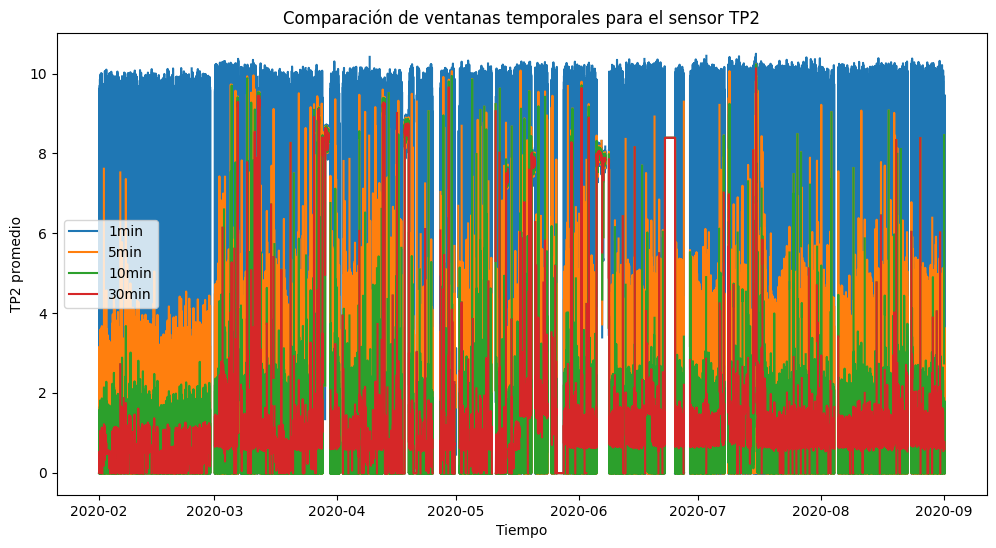

In [8]:
plt.figure(figsize=(12,6))

for w in windows:
    plt.plot(
        results[w]["TP2"]["mean"],
        label=w
    )

plt.title("Comparación de ventanas temporales para el sensor TP2")
plt.xlabel("Tiempo")
plt.ylabel("TP2 promedio")
plt.legend()
plt.show()

In [9]:
for w in windows:
    
    print("\nVentana:", w)
    
    print(
        results[w]
        .describe()
        .loc[["mean","std"]]
    )


Ventana: 1min
           TP2                               Oil_temperature            \
          mean       std       min       max            mean       std   
mean  1.380883  0.377547  0.925434  1.782753       62.642955  0.322250   
std   3.071921  1.136324  2.569974  3.707777        6.500479  0.429719   

                           Motor_current                                
            min        max          mean       std       min       max  
mean  62.223243  63.064799      2.056200  0.218108  1.809038  2.295071  
std    6.402341   6.618746      2.233016  0.586049  2.146964  2.422090  

Ventana: 5min
           TP2                               Oil_temperature            \
          mean       std       min       max            mean       std   
mean  1.383974  1.246035  0.405059  3.523776       62.621270  1.321919   
std   2.359878  1.922548  1.689239  4.769476        6.292057  1.309958   

                           Motor_current                                
           

Se evaluaron ventanas de 1, 5, 10 y 30 minutos para generar las variables del modelo.
Las ventanas pequeñas mantienen mayor detalle pero generan ruido y datasets muy grandes.
Las ventanas muy grandes suavizan demasiado las señales y pueden ocultar patrones previos a fallas.

La ventana de 5 minutos ofrece el mejor equilibrio entre reducción de ruido, preservación de patrones y tamaño del dataset, por lo que se selecciona como base para el esquema de features del modelo predictivo.